<a href="https://colab.research.google.com/github/alindote/MES_2026/blob/main/Exercicios/MES_exercicio7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as rnd

In [ ]:
# Generate 50 random locations in a 1x1 square
num_locations = 50
locations = rnd.rand(num_locations, 2)

In [ ]:
def calculate_distance(locations, path):
  total_distance = 0
  for i in range(len(path) - 1):
    total_distance += np.linalg.norm(locations[path[i]] - locations[path[i + 1]])
  return total_distance

In [ ]:
# Generate an initial random path going through all locations
initial_path = list(range(len(locations)))
rnd.shuffle(initial_path)

# calculate total distance for this initial path
initial_distance = calculate_distance(locations, initial_path)
print("Initial distance:", initial_distance)

Initial distance: 24.892968975877597


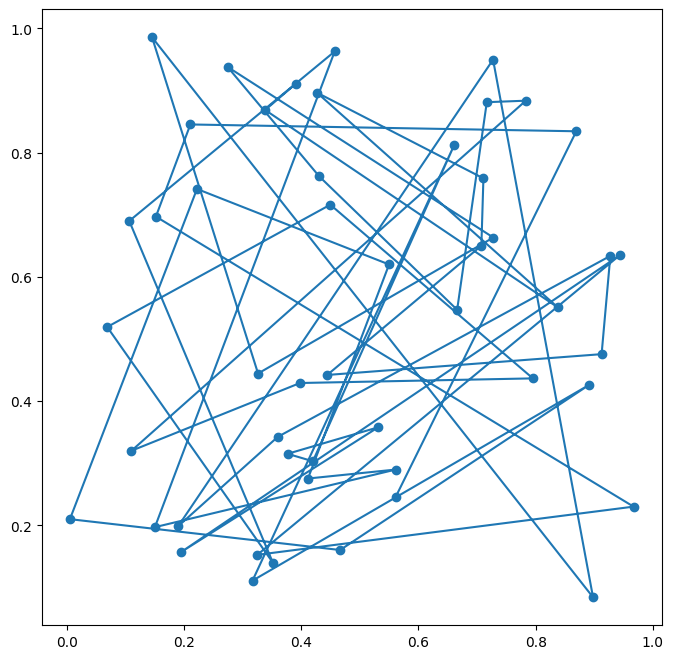

In [ ]:
# Let's visualise the initial path
plt.figure(figsize=(8, 8))
plt.plot(locations[initial_path, 0], locations[initial_path, 1], '-o')
plt.show()

In [ ]:
# initialise parameters for the Metropolis algorithm
temperature = 1  # we need to define a "temperature", may need to adjust
steps = 10000     # maximum number of steps

# implement a temperature cool down
cooldown = 0.9997

# we start the algorithm with the initial guess
current_path = initial_path.copy()
current_distance = initial_distance

# let's create an array to store the distances as we go along
distances = np.array([initial_distance])

# Start the Metropolis algorithm
for step in range(steps):

  # copy the current path and swap 2 locations
  new_path = current_path.copy()
  i, j = np.random.choice(num_locations, 2, replace=False)    # you could sample the two individually...
  new_path[i], new_path[j] = new_path[j], new_path[i]

  # calculate the total distance with the new path
  new_distance = calculate_distance(locations, new_path)

  # calculate the change in distance
  delta_distance = new_distance - current_distance

  # implement the Metropolis criterion
  if delta_distance < 0 or np.random.rand() < np.exp(-delta_distance / temperature):
    current_path = new_path
    current_distance = new_distance

  # add current distance to the array (maybe there was no change)
  distances = np.append(distances, current_distance)

  # update the temperature
  temperature *= cooldown

print('Final distance: ', current_distance)
print('Final temperature: ', temperature)

Final distance:  7.156217851955851
Final temperature:  0.002476521857428244


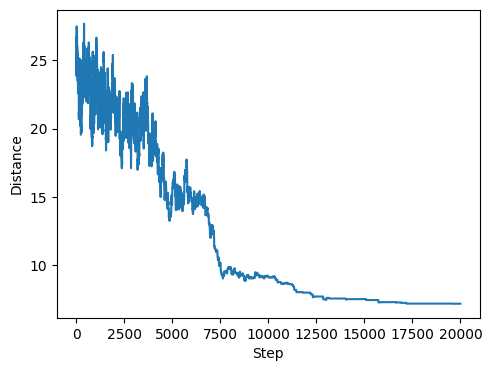

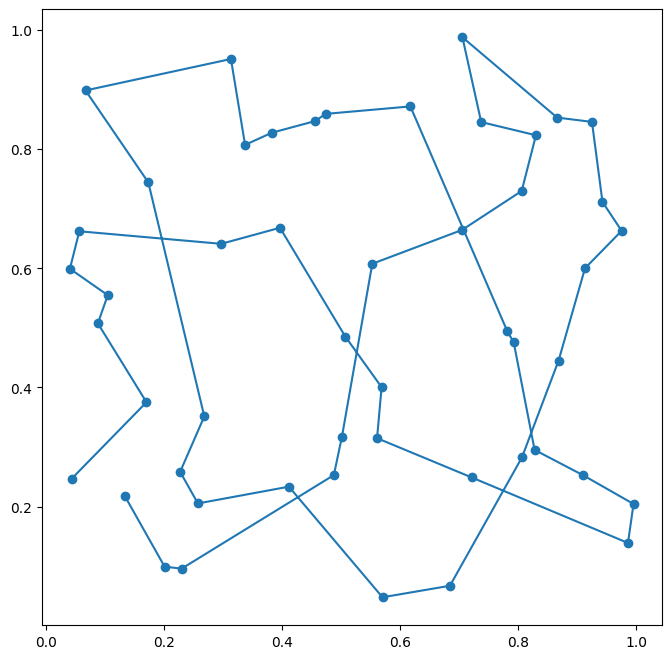

In [ ]:
# plot array with the distances and the final path
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(distances)
plt.xlabel('Step')
plt.ylabel('Distance')

# and the final path
plt.figure(figsize=(8, 8))
plt.plot(locations[current_path, 0], locations[current_path, 1], '-o')
plt.show()